# Import thư viện

In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

## Đọc dữ liệu từ file csv

In [2]:
df_qt = pd.read_csv('C:\\CS114\\qt-public.csv')
df_total = pd.read_csv('C:\\CS114\\annonimized.csv')

## Tổng quan về dữ liệu

In [3]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295198 entries, 0 to 295197
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   concat('it001',`assignment_id`)  295198 non-null  object
 1   concat('it001',`problem_id`)     295198 non-null  object
 2   concat('it001', username)        295198 non-null  object
 3   is_final                         295198 non-null  int64 
 4   status                           295198 non-null  object
 5   pre_score                        295198 non-null  int64 
 6   coefficient                      295198 non-null  int64 
 7   concat('it001',`language_id`)    295198 non-null  object
 8   created_at                       295198 non-null  object
 9   updated_at                       295198 non-null  object
 10  judgement                        295198 non-null  object
dtypes: int64(3), object(8)
memory usage: 24.8+ MB


## Tiền xử lý dữ liệu

### Đổi tên đặc trưng

In [4]:
df_total = df_total.rename(columns={
    "concat('it001', username)": "mssv",
    "concat('it001',`assignment_id`)": "assignment_id",
    "concat('it001',`problem_id`)": "problem_id",
    "pre_score": "score",
    "coefficient": "late_coef",
    "created_at": "submit_time",
    "updated_at": "judge_time",
    "concat('it001',`language_id`)": "lang_id",
    "judgement": "judgement_json"
})

### Chuyển các đặc trưng từ dạng chuỗi sang dạng số

In [5]:
df_total['code_runnable'] = (df_total['status'] == 'SCORE').astype(int)
df_total['compile_error'] = (df_total['status'] == 'Compilation Error').astype(int)
df_total['syntax_error'] = (df_total['status'] == 'Syntax Error').astype(int)
df_total['pending'] = (df_total['status'] == 'pending').astype(int)
df_total['testcase_passed_percent'] = (df_total['score'] / 100).astype(int)
df_total['submit_time'] = pd.to_datetime('2024-' + df_total['submit_time'], errors='coerce')
df_total['judge_time'] = pd.to_datetime('2024-' + df_total['judge_time'], errors='coerce')

### Encode các cột ID chuỗi thành số nguyên

In [6]:
df_encoded = df_total.copy()

# Xóa cột 'status' gốc
df_encoded = df_encoded.drop(columns=['status'])

# Encode các cột ID chuỗi thành số nguyên
for col in ['assignment_id', 'problem_id', 'lang_id']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

### Trích xuất thông tin từ cột judgement_json, sau đó xóa cột đó đi

In [7]:
def extract_judgement_features(row):
    try:
        data = json.loads(row)
        times = data.get("times", [])
        mems = data.get("mems", [])
        failed = data.get("failed", [])

        n_tests = len(times)
        n_failed = len(failed)
        failed_ratio = n_failed / n_tests if n_tests > 0 else 0

        avg_time = np.mean(times) if times else 0
        max_time = np.max(times) if times else 0

        avg_mem = np.mean(mems) if mems else 0
        max_mem = np.max(mems) if mems else 0

        return pd.Series([n_tests, n_failed, failed_ratio, avg_time, max_time, avg_mem, max_mem])

    except:
        return pd.Series([0, 0, 0, 0, 0, 0, 0])

# Áp dụng trích xuất vào dataframe
df_encoded[['n_tests', 'n_failed', 'failed_ratio', 'avg_time', 'max_time', 'avg_mem', 'max_mem']] = df_encoded['judgement_json'].apply(extract_judgement_features)

df_encoded = df_encoded.drop(columns=['judgement_json'])

### Nhóm các dòng dữ liệu theo cột mssv

In [8]:
# Group theo mssv để tổng hợp
features_by_mssv = df_encoded.groupby('mssv').agg({
    'assignment_id': pd.Series.nunique,                 # Số assignment đã tham gia
    'problem_id': pd.Series.nunique,                    # Số bài đã làm
    'code_runnable': ['sum', 'mean'],                   # Tổng số bài chạy được và tỷ lệ
    'testcase_passed_percent': 'mean',                  # Trung bình testcase đúng
    'late_coef': 'mean',                                # Trung bình hệ số trễ
    'n_failed': 'mean',                                 # Trung bình số test case sai
    'failed_ratio': 'mean',                             # Tỷ lệ test case sai trung bình
    'avg_time': ['mean', 'max'],                        # Trung bình + max thời gian chạy
    'avg_mem': ['mean', 'max'],                         # Trung bình + max bộ nhớ
    'lang_id': pd.Series.nunique,                       # Số ngôn ngữ đã dùng
    'compile_error': 'sum',                             # Tổng lần bị compile error
    'syntax_error': 'sum'                               # Tổng lần bị syntax error
})

# Đặt lại tên cột cho dễ hiểu
features_by_mssv.columns = [
    'n_assignments', 'n_problems', 
    'n_code_runnable', 'code_runnable_ratio', 
    'avg_testcase_passed', 'avg_late_coef', 
    'avg_n_failed', 'avg_failed_ratio', 
    'avg_time', 'max_time',
    'avg_mem', 'max_mem',
    'n_lang_used', 'n_compile_error', 'n_syntax_error'
]

# Reset index để mssv là cột
features_by_mssv = features_by_mssv.reset_index()

# Kiểm tra kết quả
print(features_by_mssv.head())


                                       mssv  n_assignments  n_problems  \
0  00b6dd4fc7eb817e03708c532016ef30ce564a61              7          46   
1  00bef8afee8f3c595d535c9c03c490cac1a4f021              9          78   
2  01122b3ef7e59b84189e65985305f575d6bdf83c              7          66   
3  0134f9f410c65ad0e8c2254a7e9288670e02a183              4          47   
4  013de369c439ab0ead8aa7da64423aa395a8be39              8          52   

   n_code_runnable  code_runnable_ratio  avg_testcase_passed  avg_late_coef  \
0              119             0.809524            54.931973     100.000000   
1              209             0.806950            54.818533     100.000000   
2              175             0.897436            59.620513     100.000000   
3               76             0.760000            59.510000     100.000000   
4               94             0.878505            64.663551      97.196262   

   avg_n_failed  avg_failed_ratio  avg_time  max_time     avg_mem  \
0          

## Tiền xử lý dữ liệu điểm thực hành

### Tổng quan về điểm thực hành

In [9]:
df_qt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   hash    761 non-null    object
 1   diemqt  755 non-null    object
dtypes: object(2)
memory usage: 12.0+ KB


In [10]:
df_qt.isna().sum()

hash      0
diemqt    6
dtype: int64

### Đổi tên cột hash thành mssv

In [11]:
df_qt.rename(columns={'hash': 'mssv'}, inplace=True)

### Chuyển cột điểm quá trình từ dạng chuỗi thành dạng số

In [12]:
df_qt['diemqt'] = pd.to_numeric(df_qt['diemqt'], errors='coerce')

### Loại bỏ các dòng có cột điểm quá trình bị thiếu dữ liệu

In [13]:
df_qt = df_qt.dropna(subset=['diemqt'])

### Kiểm tra lại dữ liệu một lần nữa

In [14]:
df_qt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 754 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mssv    754 non-null    object 
 1   diemqt  754 non-null    float64
dtypes: float64(1), object(1)
memory usage: 17.7+ KB


## Ghép dữ liệu các cột đặc trưng với dữ liệu điểm thông qua mssv

In [15]:
df_merged = features_by_mssv.merge(df_qt, on='mssv', how='left')

### kiểm tra dữ liệu sau khi ghép

In [16]:
df_merged.head()

,mssv,n_assignments,n_problems,n_code_runnable,code_runnable_ratio,avg_testcase_passed,avg_late_coef,avg_n_failed,avg_failed_ratio,avg_time,max_time,avg_mem,max_mem,n_lang_used,n_compile_error,n_syntax_error,diemqt
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,119,0.809524,54.931973,100.000000,0.0,0.0,0.013624,0.510769,91.583424,1818.666667,1,28,0,7.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,209,0.806950,54.818533,100.000000,0.0,0.0,0.010982,0.606154,172.903711,1984.000000,1,50,0,7.0
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,175,0.897436,59.620513,100.000000,0.0,0.0,0.017795,0.524000,186.855543,10200.000000,1,20,0,9.0
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,4,47,76,0.760000,59.510000,100.000000,0.0,0.0,0.006643,0.534000,39.750857,1984.000000,1,24,0,NaN
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,94,0.878505,64.663551,97.196262,0.0,0.0,0.031732,0.803571,186.571709,1785.600000,1,13,0,10.0


### kiểm tra giá trị có trong dữ liệu

In [17]:
df_merged.describe()

,n_assignments,n_problems,n_code_runnable,code_runnable_ratio,avg_testcase_passed,avg_late_coef,avg_n_failed,avg_failed_ratio,avg_time,max_time,avg_mem,max_mem,n_lang_used,n_compile_error,n_syntax_error,diemqt
count,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.0,1489.0,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,754.000000
mean,7.232371,62.612492,158.160510,0.801615,51.772765,99.545852,0.0,0.0,0.022094,0.465487,300.729874,7511.175702,1.046340,40.047011,0.038281,8.294430
std,3.774526,33.158967,104.863514,0.130724,15.066336,2.403329,0.0,0.0,0.051101,0.580963,861.693985,17937.264135,0.225705,36.488626,0.666407,1.745279
min,1.000000,1.000000,0.000000,0.000000,0.000000,51.612903,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5.000000,41.000000,87.000000,0.748538,44.363636,100.000000,0.0,0.0,0.003474,0.234167,52.683799,1984.000000,1.000000,15.000000,0.000000,7.500000
50%,6.000000,62.000000,145.000000,0.822695,53.031250,100.000000,0.0,0.0,0.011260,0.525000,121.979194,2128.000000,1.000000,32.000000,0.000000,9.000000
75%,10.000000,93.000000,216.000000,0.876652,60.787234,100.000000,0.0,0.0,0.023762,0.604231,239.309528,8823.200000,1.000000,54.000000,0.000000,9.500000
max,23.000000,143.000000,787.000000,1.000000,100.000000,100.000000,0.0,0.0,0.923846,20.010000,13423.358025,290291.542857,3.000000,334.000000,24.000000,10.000000


### Kiểm tra xem có dòng nào bị thiếu dữ liệu không

In [18]:
df_merged.isna().sum()

mssv                     0
n_assignments            0
n_problems               0
n_code_runnable          0
code_runnable_ratio      0
avg_testcase_passed      0
avg_late_coef            0
avg_n_failed             0
avg_failed_ratio         0
avg_time                 0
max_time                 0
avg_mem                  0
max_mem                  0
n_lang_used              0
n_compile_error          0
n_syntax_error           0
diemqt                 735
dtype: int64

LOẠI BỎ ĐẶC TRƯNG SAU KHI TRAIN LẦN TRƯỚC ĐÓ

In [19]:
df_merged = df_merged.drop(columns=['avg_failed_ratio'])
df_merged = df_merged.drop(columns=['avg_n_failed'])
df_merged = df_merged.drop(columns=['n_lang_used'])
df_merged = df_merged.drop(columns=['n_syntax_error'])
df_merged = df_merged.drop(columns=['avg_late_coef'])

### Chia dữ liệu thành tập train / test

In [20]:
train_df = df_merged[df_merged['diemqt'].notna()]
test_df = df_merged[df_merged['diemqt'].isna()]

X_train = train_df.drop(columns=['mssv', 'diemqt'])
y_train = train_df['diemqt']

X_test = test_df.drop(columns=['mssv', 'diemqt'])

### Huấn luyện bằng mô hình Random Forest, sử dụng Randomized Search để tìm bộ siêu tham số dự đoán kết quả tốt nhất

In [21]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='r2',
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='r2', verbose=2)

### Bộ siêu tham số tốt nhất tốt nhất

In [22]:
best_model = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}


### Đánh giá trên tập huấn luyện

In [23]:
y_pred_train = best_model.predict(X_train)
print("R^2 score trên tập huấn luyện:", r2_score(y_train, y_pred_train))

R^2 score trên tập huấn luyện: 0.5616575724219707


### Dự đoán kết quả trên tập test

In [24]:
test_df['diemqt'] = best_model.predict(X_test)

C:\Users\MrBeast\AppData\Local\Temp\ipykernel_3868\353606744.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['diemqt'] = best_model.predict(X_test)


### Lưu kết quả điểm vào file csv để nộp

In [25]:
submission = test_df[['mssv', 'diemqt']]
submission[['mssv', 'diemqt']].to_csv('result.csv', index=False, header=False, encoding='utf-8')

### Lưu bộ siêu tham số tốt nhất

In [26]:
joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']

### In ra bộ siêu tham số tốt nhất

In [27]:
model = joblib.load('best_model.pkl')

print(model)

# Xem các tham số mô hình
print(model.get_params())

RandomForestRegressor(max_depth=20, max_features='log2', min_samples_leaf=4,
                      random_state=42)
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


### In ra các đặc trưng quan trọng

In [28]:
print(model.feature_importances_)

[0.09316916 0.12412405 0.11371556 0.13238206 0.13306652 0.07243856
 0.07407488 0.10647935 0.05567358 0.09487628]


### Vẽ biểu đồ các đặc trưng quan trọng

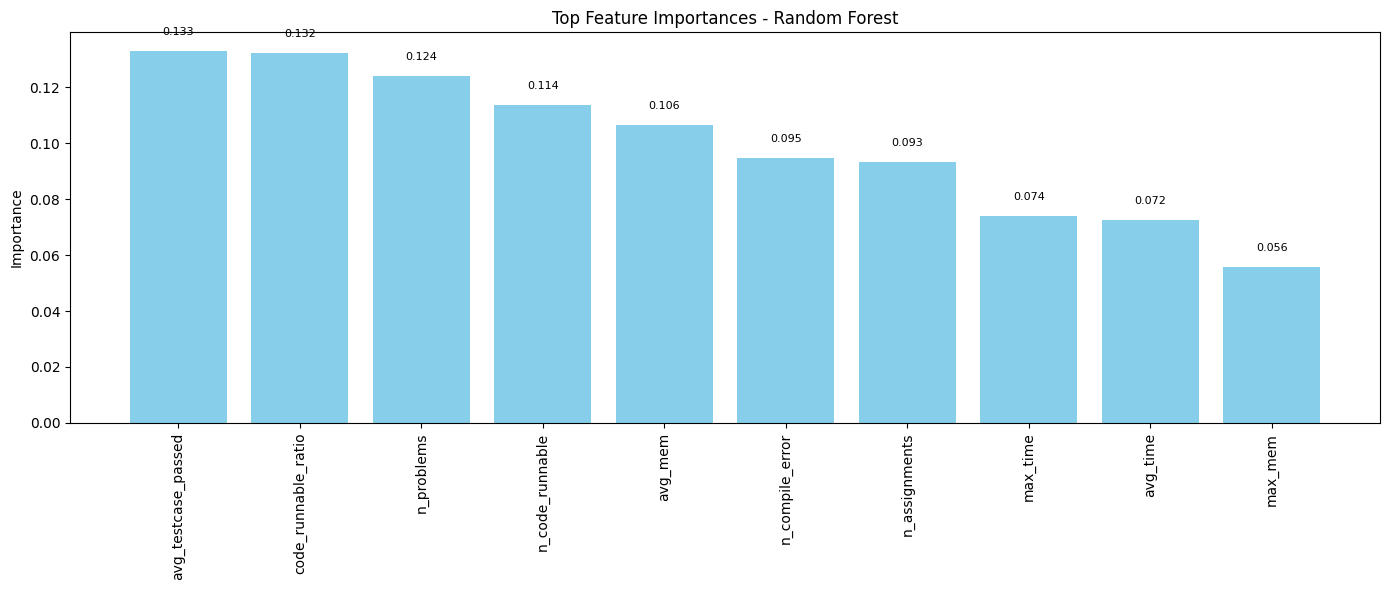

In [29]:
importances = model.feature_importances_
feature_names = X_train.columns

indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

top_k = min(20, len(importances))
sorted_importances = sorted_importances[:top_k]
sorted_features = sorted_features[:top_k]

# Vẽ
plt.figure(figsize=(14, 6))
bars = plt.bar(range(top_k), sorted_importances, color='skyblue', align='center')
plt.xticks(range(top_k), sorted_features, rotation=90)
plt.title('Top Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()

# Ghi nhãn số
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.005, f'{height:.3f}', 
             ha='center', va='bottom', fontsize=8)

plt.show()
